In [73]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results
from stable_baselines3.common import results_plotter

from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory

In [75]:


# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([5.0, 0.01])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high), c_r_RH (RH penalty)]
custom_penalty_coefs = np.array([0.001, 0.001, 0.001, 0.003, 0.001, 0.001, 0.001, 0.03])

weather_file = root_dir + r"\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat"

log_dir = "tmp"
os.makedirs(log_dir, exist_ok=True)

env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs,
    n_days=5
)
monitor = Monitor(env, log_dir)

In [86]:

# Initialize the Soft Actor-Critic model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SAC("MlpPolicy", monitor, verbose=1, learning_rate=1e-4, batch_size=64, device='cpu')
# Train for at least one full episode so Monitor writes a completed episode row.
model.learn(total_timesteps=30000, log_interval=100, progress_bar=True)
model.save("sac_lettuce_greenhouse")

Output()

Using cpu device
Wrapping the env in a DummyVecEnv.


In [87]:
import os
monitor_path = os.path.join(log_dir, "monitor.csv")
print("Training episode length (timesteps):", env.N)
print("Monitor log path:", monitor_path)
if os.path.exists(monitor_path):
    with open(monitor_path, "r") as monitor_file:
        lines = monitor_file.readlines()
    print("Monitor file rows:", len(lines) - 1)
    print("Monitor file content:\n", "".join(lines[-10:]))
else:
    print("Monitor file not found.")

Training episode length (timesteps): 480
Monitor log path: tmp\monitor.csv
Monitor file rows: 83
Monitor file content:
 -33.49287,480,453.788676
-34.179075,480,459.193298
-24.049795,480,465.766144
-22.548181,480,471.64068
-2.758846,480,476.905848
-4.267171,480,481.872999
2.059276,480,486.194899
-0.847751,480,492.053491
-9.964397,480,498.16142
-0.289531,480,503.425757



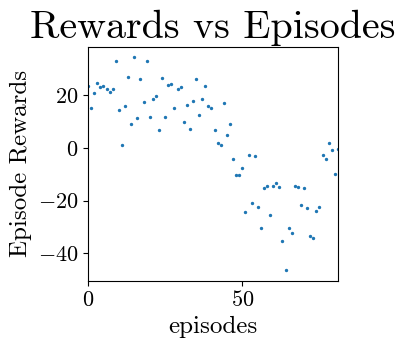

In [88]:
import matplotlib.pyplot as plt
from stable_baselines3.common import results_plotter

# Plot by timesteps (shows sample efficiency)
# plot_results([log_dir], None, results_plotter.X_TIMESTEPS, "Rewards vs Timesteps")
# By episodes:]


plot_results([log_dir], None, results_plotter.X_EPISODES, "Rewards vs Episodes",figsize=(4,4))
# plot_results([log_dir], None, results_plotter.X_WALLTIME, "Rewards vs Time")
plt.show()


In [89]:
# We must reset the environment before testing
from aml_project.common.helper_functions import weather2ppmrh


obs, info = env.reset()

done = False
truncated = False

# Initialize arrays to store measurements, actions, and rewards
y = np.zeros((env.N+1, env.ny))
u = np.zeros((env.N, env.action_space.shape[0]))
rewards = np.zeros((env.N, 1))

# Set initial state and action
y[0] = obs[:env.ny]
env.prev_action = np.zeros(env.action_space.shape[0])

# Initialize loop variables
k = 0
terminated = False
done = False
accumulated_reward = np.zeros((env.N, 1))
# Generate trajectory until termination
while not terminated and not done:
    # Predict the action using the trained model
    action, _states = model.predict(obs, deterministic=True)
    
    # Take the action in the environment
    obs, reward, done, truncated, info = env.step(action)

    # Store the previous action
    u[k] = env.prev_action

    # Store the observation as a measurement
    y[k+1] = obs[:env.ny]

    # Accumulate the reward
    rewards[k] += reward
    accumulated_reward[k] = rewards[:k+1].sum()
    # Increment the step counter
    k += 1

# Return the generated trajectory
y = y[:env.N]
d = weather2ppmrh(env.d[:env.N])
u = u[:env.N]
r = rewards[:env.N]


Plotting results...


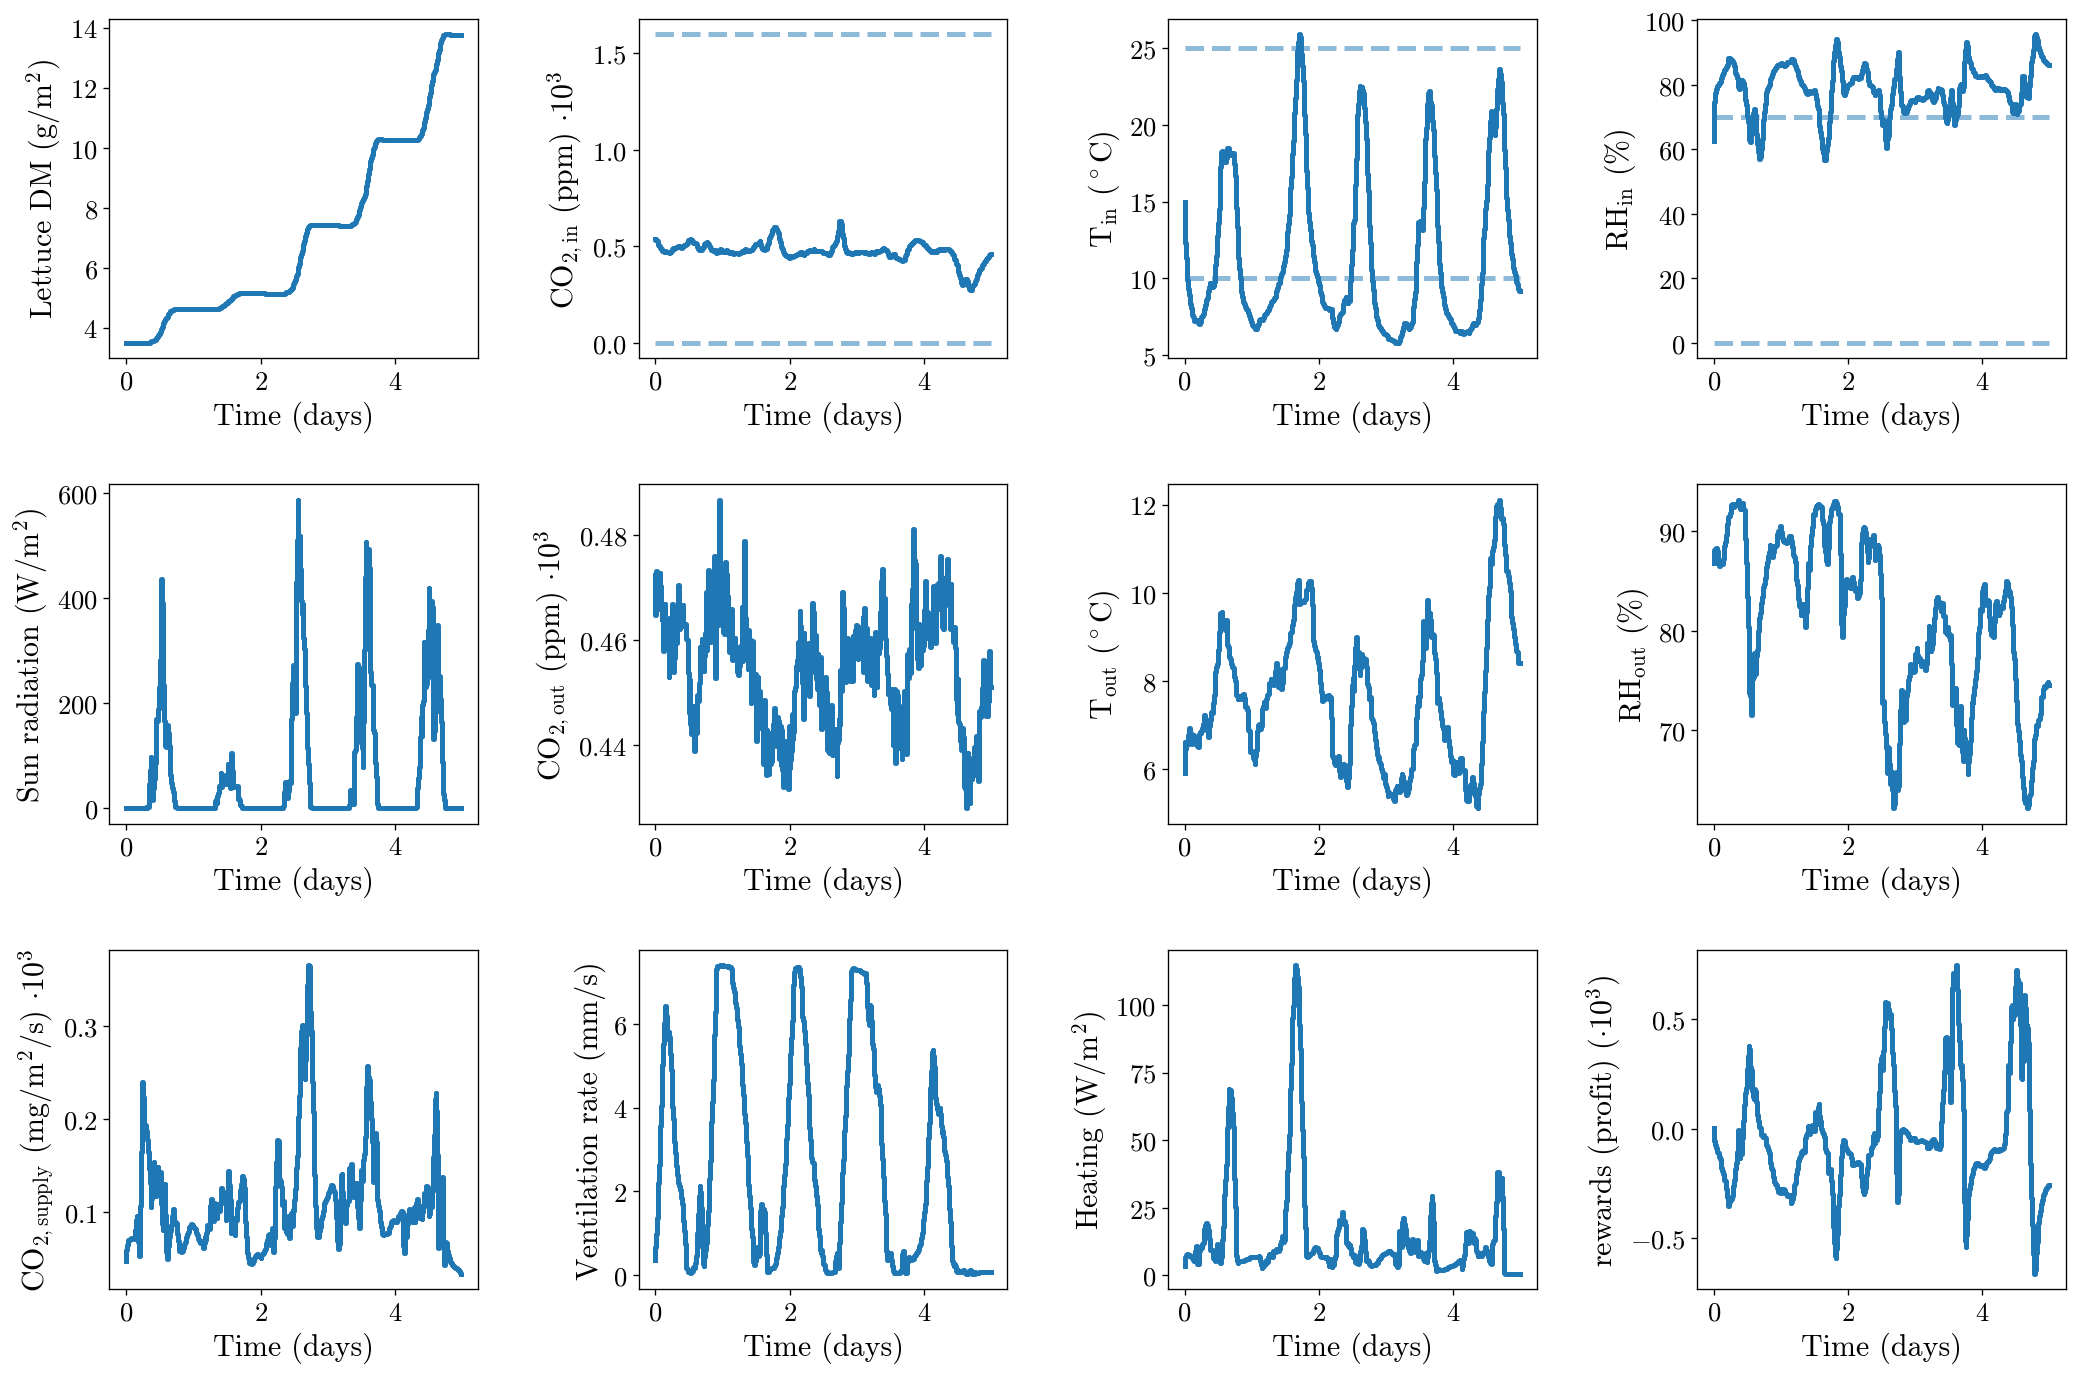

In [90]:
print("Plotting results...")

nvars = 12
# plot the resulting trajectory
n_per_day = int(24*3600/env.h) # control frequency per day
label= 'Trained SAC policy'
trajectory = np.concatenate((y, d, u, r), axis=1)
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, env.obs_low, env.obs_high)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 0, env.n_days, n_per_day, label)

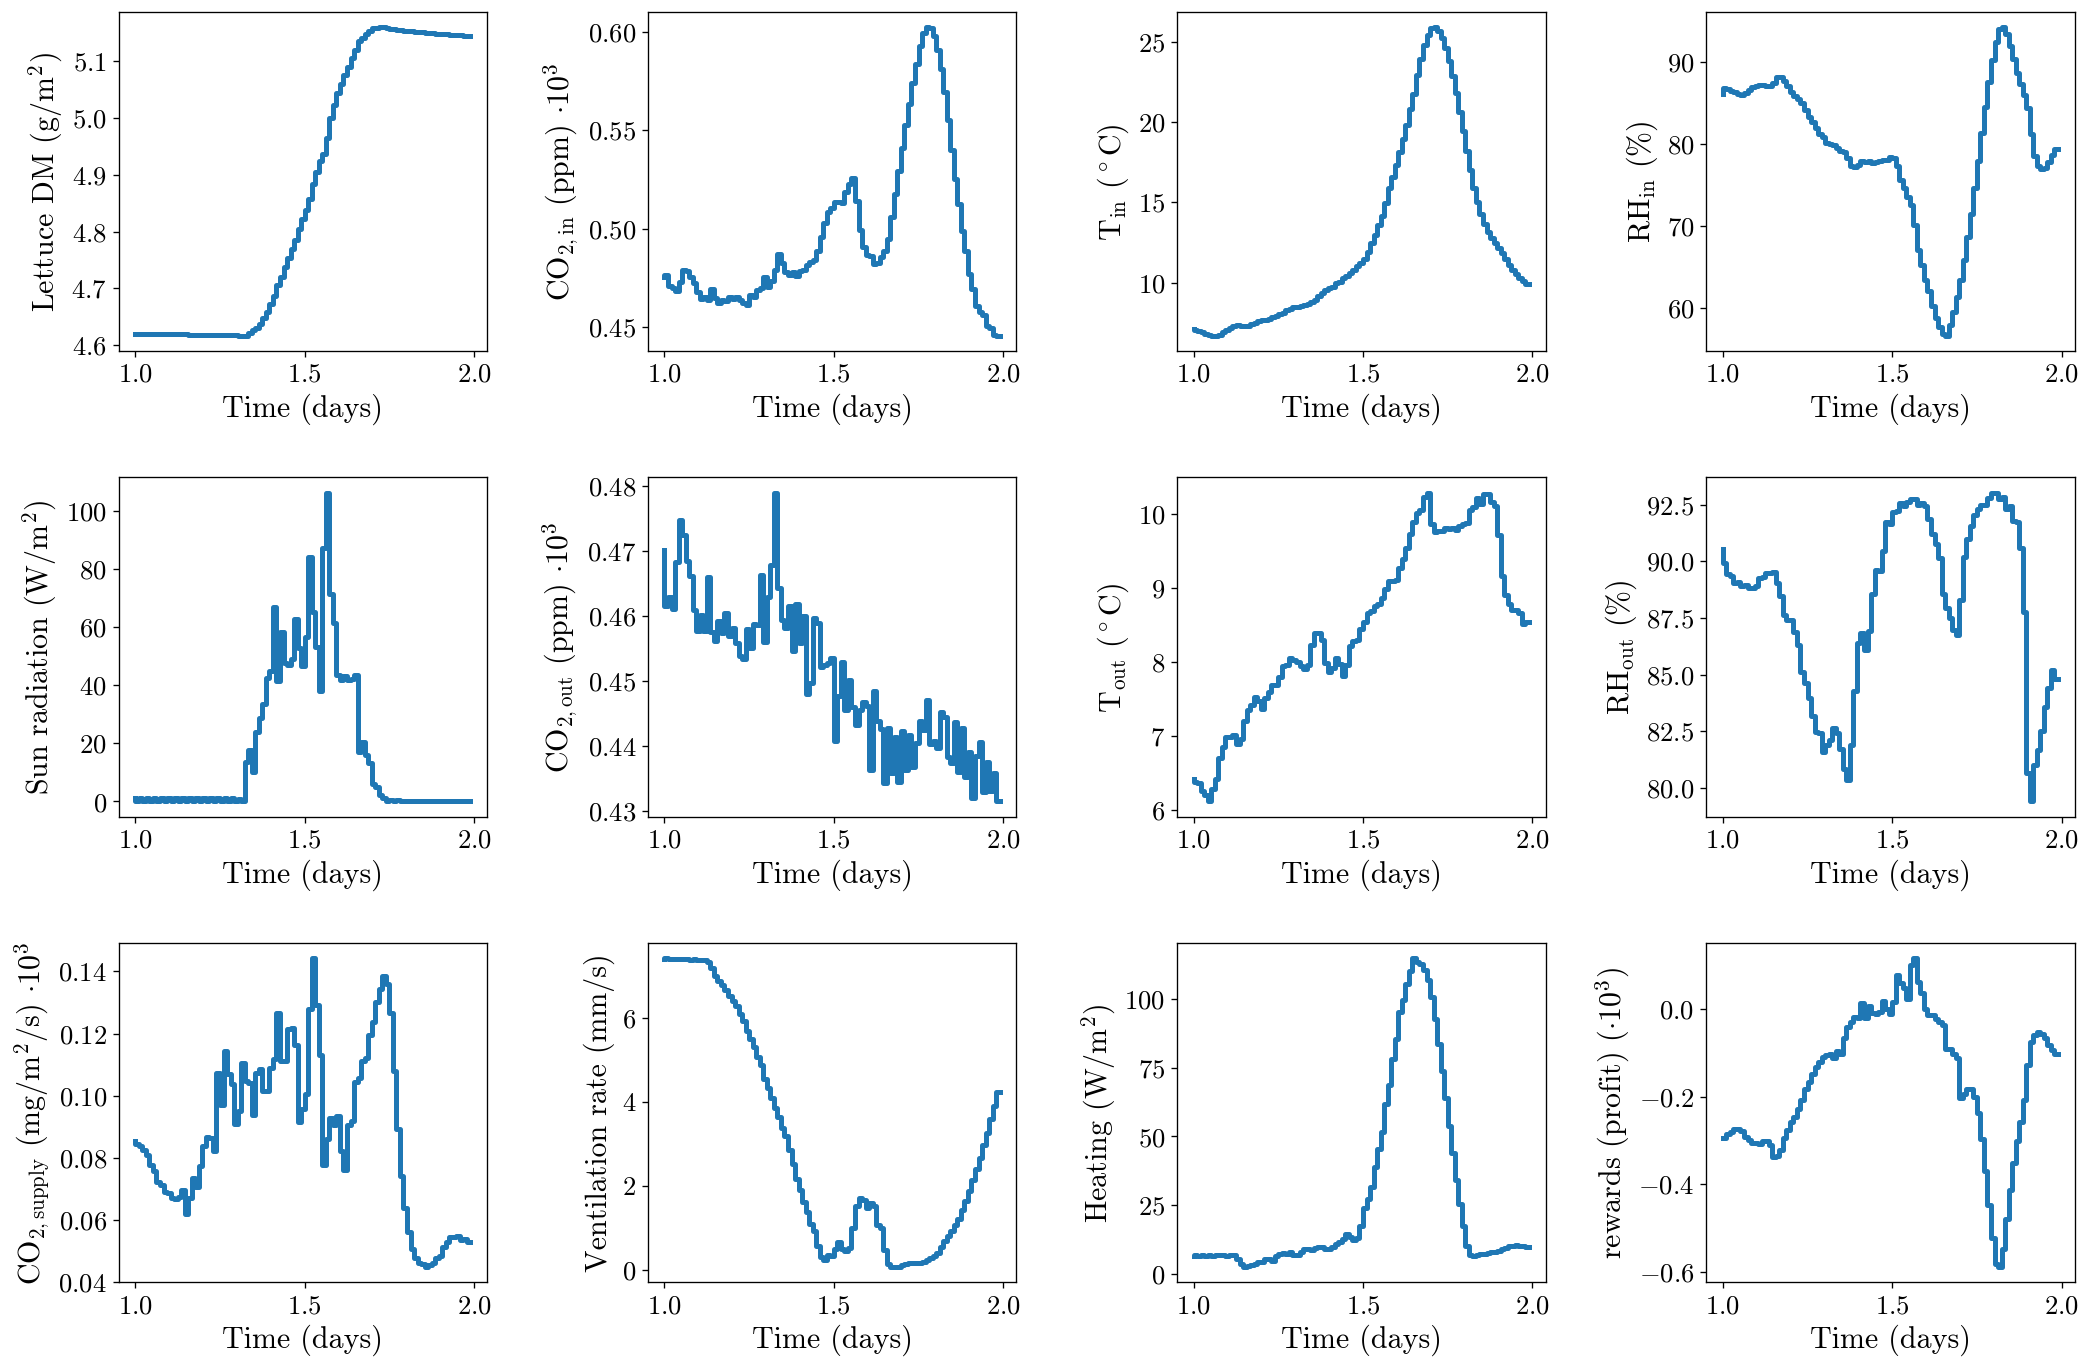

In [91]:
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, None, None)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 1, 1, n_per_day, label)

In [82]:
def run_zero_input_baseline(env):
    # First heuristic where we hold all inputs at 0 (minimum)
    obs, info = env.reset()
    terminated = False
    done = False
    
    # Action space is scaled between -1 and 1. -1 corresponds to 0 physical input.
    zero_action = np.array([-1.0, -1.0, -1.0], dtype=np.float32) 
    
    while not terminated and not done:
        obs, reward, terminated, truncated, info = env.step(zero_action)
        
    return info['profit'].sum(), info


def run_heuristic_baseline(env):
    # Second heuristic where we dose CO2 if below 850 ppm, heat if below 16C, and ventilate if above 19.5C
    obs, info = env.reset()
    terminated = False
    done = False
    
    while not terminated and not done:
        # obs[:4] corresponds to greenhouse measurements: [dry_weight, co2_ppm, temp_c, rh]
        co2_ppm = obs[1]
        temp_c = obs[2]
        
        # CO2 Dosing 
        co2_act = 0.2 if co2_ppm < 850 else -1.0
        
       # Temperature 
        if temp_c < 16.0:
            heat_act = 0.5  # Turn on heating
            vent_act = -1.0 # Close vents to trap heat
        elif temp_c > 19.5:
            heat_act = -1.0 # Turn off heating
            vent_act = 0.3  # Open vents to cool down
        else:
            heat_act = -1.0 # Optimal band: do nothing
            vent_act = -1.0
            
        action = np.array([co2_act, vent_act, heat_act], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        
    return info['profit'].sum(), info

In [83]:
# Actual evaluation of the trained SAC agent
sac_total_profit = info['profit'].sum()

zero_profit, zero_info = run_zero_input_baseline(env)
heuristic_profit, heuristic_info = run_heuristic_baseline(env)

print(f"--- Cumulative Profit Comparison ---")
print(f"Zero-Input Baseline Profit : {zero_profit:.2f}")
print(f"Heuristic Baseline Profit  : {heuristic_profit:.2f}")
print(f"Trained SAC Agent Profit   : {sac_total_profit:.2f}")

--- Cumulative Profit Comparison ---
Zero-Input Baseline Profit : 30.78
Heuristic Baseline Profit  : 88.16
Trained SAC Agent Profit   : 41.12
